<a href="https://colab.research.google.com/github/MEdan-US/Mini-Project/blob/mon083/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Prelimaniries

## Import and Configuration

Sử dụng thư viện nào thì điền ở đây, không ghi dưới code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style='whitegrid')
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Mute warnings
warnings.filterwarnings('ignore')
print('Import Library Successfully')

Import Library Successfully


## Prepare dataset

In [2]:
!gdown 1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh

Downloading...
From: https://drive.google.com/uc?id=1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh
To: /content/ai_student_impact_dataset.csv
100% 5.89M/5.89M [00:00<00:00, 25.2MB/s]


In [3]:
DATA_PATH="/content/ai_student_impact_dataset.csv"
df=pd.read_csv(DATA_PATH,index_col="Student_ID")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  Skill_Retention_Score       50

Biến Target là `Post_Semester GPA`

# Step 1: Exploratory Data Analysis

## Numerical Features (Mon)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu cụ thể (int64, float64).
  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) trên từng biến định lượng và đề xuất hướng xử lý (điền bằng mean, median hay xóa).
- Thống kê mô tả (Descriptive Statistics):
  - Tính toán các chỉ số cơ bản: Trung bình (Mean), Trung vị (Median), Độ lệch chuẩn (Std), Giá trị lớn nhất/nhỏ nhất (Min/Max), và các khoảng tứ phân vị (25%, 50%, 75%).
  - Vẽ biểu đồ phân phối (Histogram, KDE Plot) để xem dữ liệu có bị lệch (Skewed) hay tuân theo phân phối chuẩn không.
  - Phát hiện dữ liệu dị biệt (Outliers) bằng biểu đồ Boxplot hoặc phương pháp IQR / Z-score.
- Phân tích mức độ tương quan :
  - Vẽ ma trận tương quan (Correlation Matrix / Heatmap) giữa các biến định lượng với nhau để tìm ra hiện tượng đa cộng tuyến (Multicollinearity).
  - Vẽ Scatter Plot giữa các biến định lượng quan trọng để thấy xu hướng tuyến tính hoặc phi tuyến.

In [6]:
numerical_data=df.select_dtypes(include=['int64', 'float64'])
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pre_Semester_GPA            50000 non-null  float64
 1   Weekly_GenAI_Hours          50000 non-null  float64
 2   Tool_Diversity              50000 non-null  int64  
 3   Traditional_Study_Hours     50000 non-null  float64
 4   Perceived_AI_Dependency     50000 non-null  int64  
 5   Anxiety_Level_During_Exams  50000 non-null  int64  
 6   Post_Semester_GPA           50000 non-null  float64
 7   Skill_Retention_Score       50000 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 3.4 MB


In [7]:
numerical_cols = numerical_data.columns.tolist()
numerical_cols

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [8]:
# Cấu trúc dữ liệu
missing_summary = pd.DataFrame({
    'Kiểu dữ liệu': df[numerical_cols].dtypes,
    'Tỉ lệ khuyết (%)': (df[numerical_cols].isnull().sum()/len(df))*100
})
print(missing_summary)

                           Kiểu dữ liệu  Tỉ lệ khuyết (%)
Pre_Semester_GPA                float64               0.0
Weekly_GenAI_Hours              float64               0.0
Tool_Diversity                    int64               0.0
Traditional_Study_Hours         float64               0.0
Perceived_AI_Dependency           int64               0.0
Anxiety_Level_During_Exams        int64               0.0
Post_Semester_GPA               float64               0.0
Skill_Retention_Score           float64               0.0


- Không có cột nào bị thiếu

In [9]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [10]:
# Skew của phân phối
print(numerical_data.skew())

Pre_Semester_GPA             -0.602043
Weekly_GenAI_Hours            1.609772
Tool_Diversity                0.166799
Traditional_Study_Hours       0.130072
Perceived_AI_Dependency       0.655365
Anxiety_Level_During_Exams    0.361730
Post_Semester_GPA            -0.675059
Skill_Retention_Score        -0.215181
dtype: float64


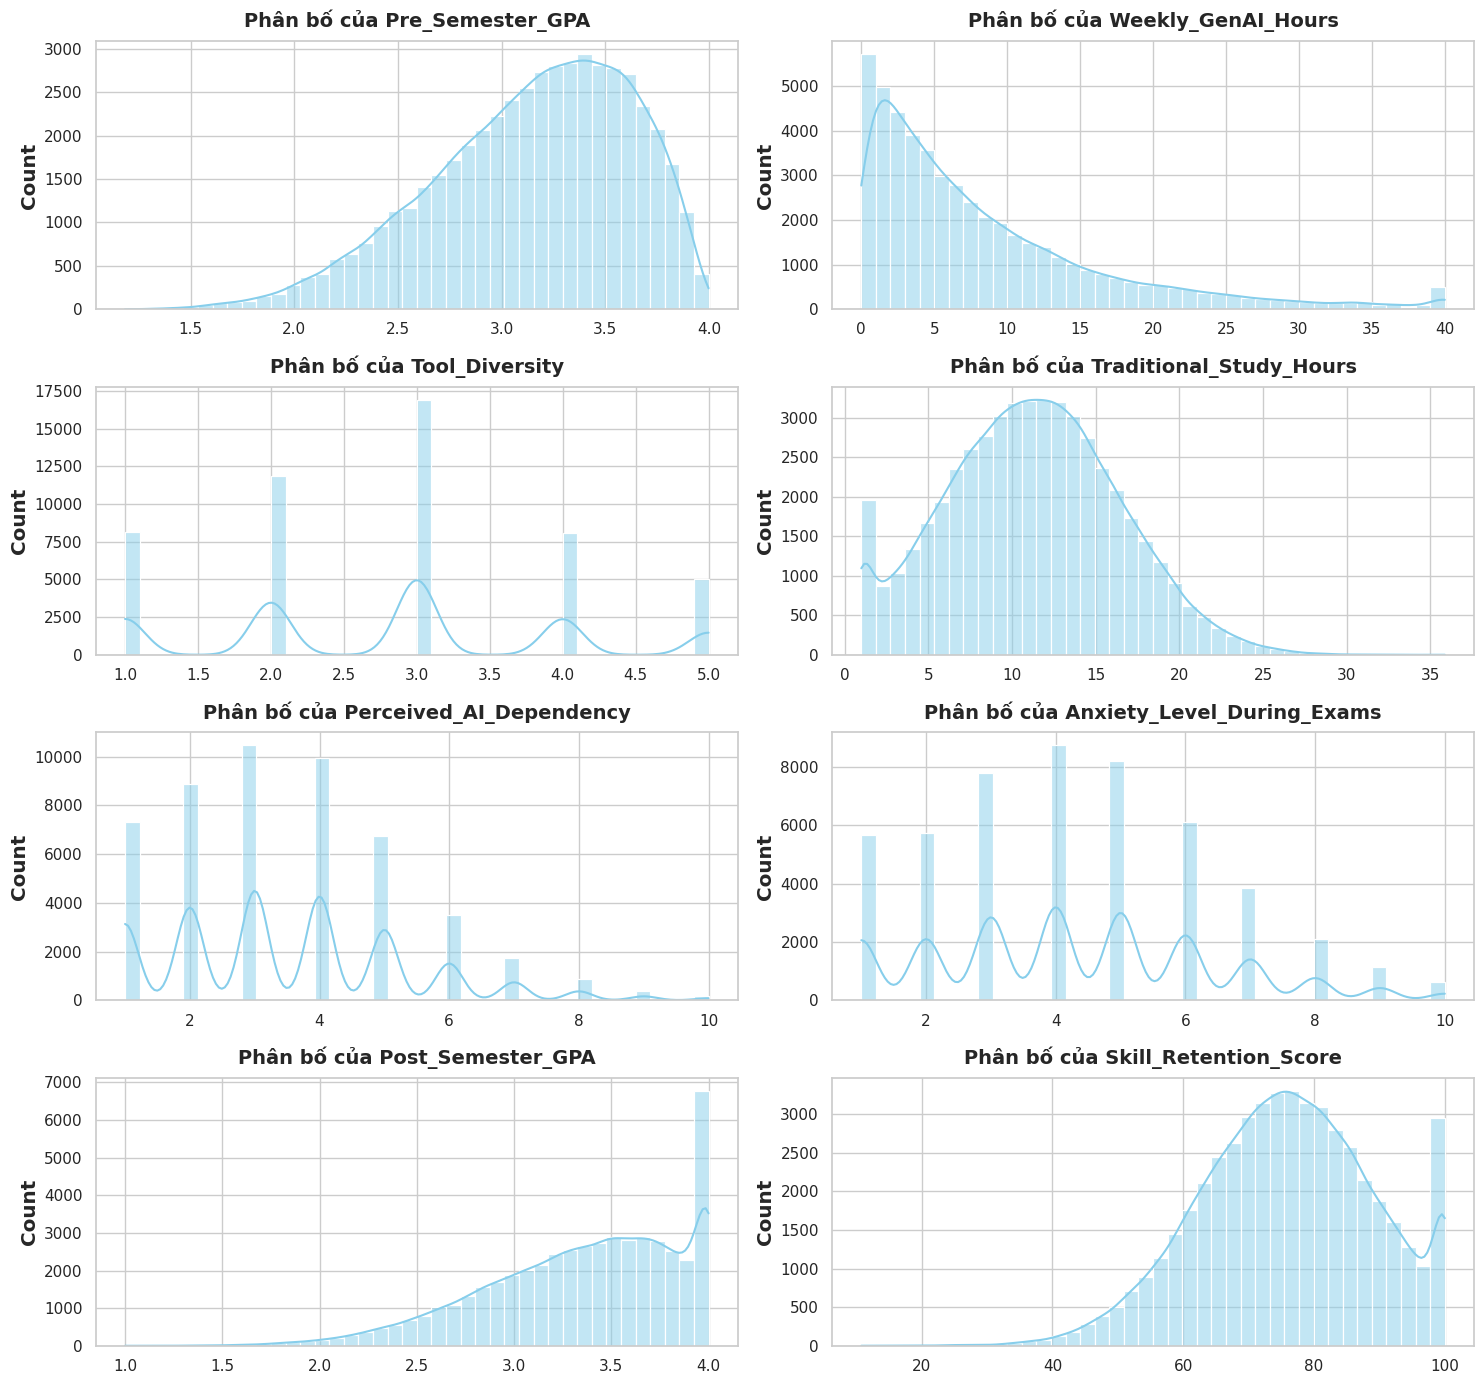

In [11]:
# Biểu đồ phân phối
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=40)
    axes[i].set_title(f'Phân bố của {col}', fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Pre_Semester_GPA**: Lệch trái, phần lớn sinh viên có GPA cao (tập trung từ mốc 3.0-3.5).

- **Weekly_GenAI_Hours**: Lệch phải nặng, phần lớn sinh viên dùng AI rất ít (<5 tiếng/tuần). Tuy nhiên có một nhóm nhỏ lạm dụng AI khoảng 40 tiếng/tuần (có mốc gồ lên ở mức 40).

- **Tool_Diversity**: Đạt đỉnh ở mốc 3, đa số sinh viên dùng khoảng 3 công cụ.

- **Traditional_Study_Hours:** Phân bố khá đối xứng, đạt đỉnh ở khoảng 11-12 tiếng. Tuy nhiên ở mốc đầu (<3 tiếng) lại vọt lên cao bất thường (có thể là những sinh viên dùng AI nhiều hoặc lười học).

- **Perceived_AI_Dependency:** Có độ lệnh phải nhẹ. Phần lớn mức độ phụ thuộc của sinh viên ở mức nhẹ (2-4), ít người phụ thuộc nặng (>8).

- **Anxiety_Level_During_Exams:** Có độ lệch phải nhẹ. Phần lớn mức độ lo lắng của sinh viên ở mức nhẹ (2-5), ít người lo lắng cực đoan (>8).

- **Post_Semester_GPA: Lệch trái**. Phần lớn sinh viên có GPA sau học kỳ ở mức cao (từ 3.0 trở lên). Đặc biệt ở mốc 4.0 vọt lên cao bất thường so với Pre_Semester_GPA (có thể việc dùng AI đã buff điểm cao lên vọt).

- **Skill_Retention_Score:** Đa số sinh viên giữ được kỹ năng ở mức khá cao (70-80). Tuy nhiên mốc 100 lại cao vọt lên bất thường y hệt trường hợp của GPA đều cao ở mốc cuối, có thể việc dùng AI đã buff điểm cao lên vọt.


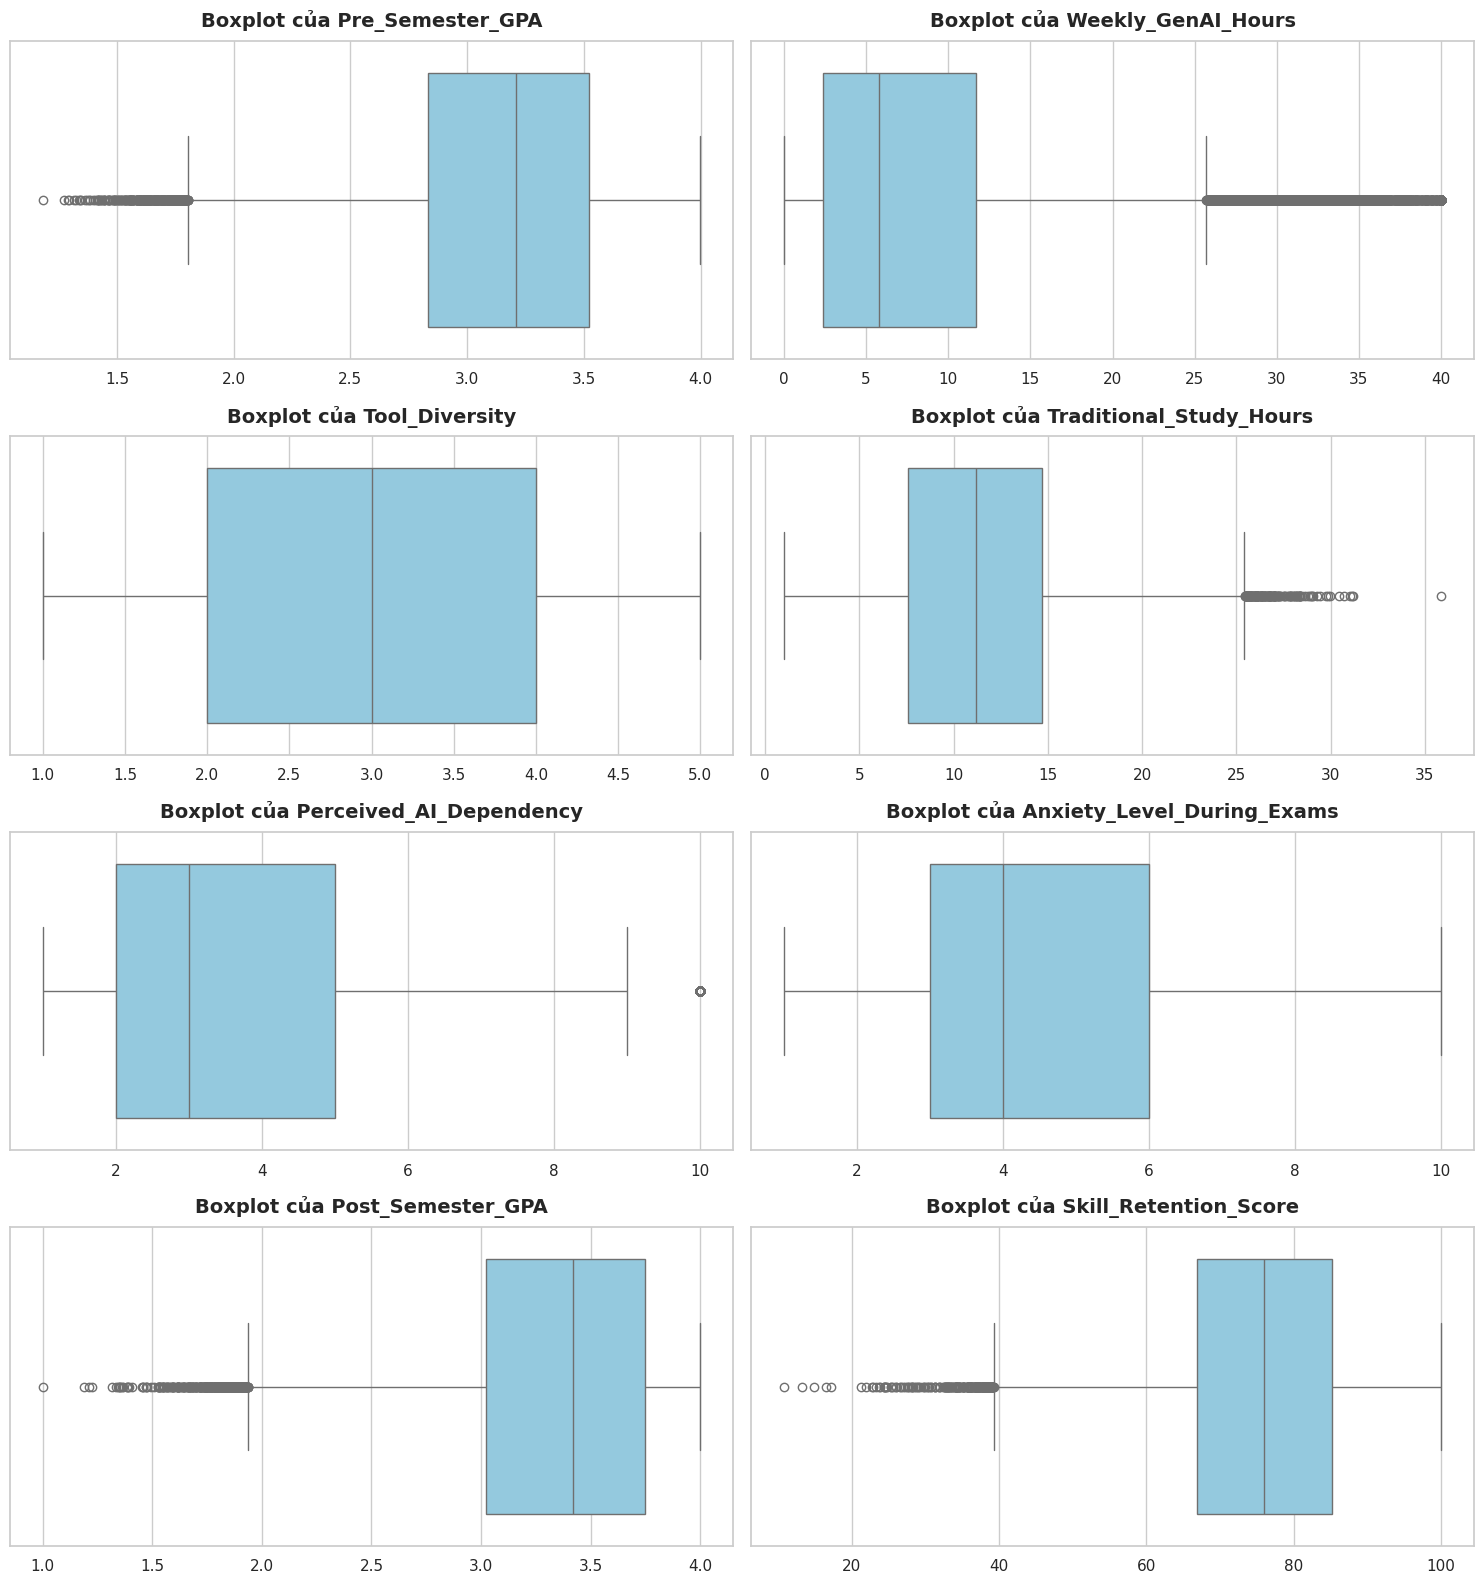

In [12]:
# Boxplot
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x = df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot của {col}', fontweight="bold")
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Pre_Semester_GPA, Post_Semester_GPA, Skill_Retention_Score** đều có dải ngoại lai kéo dài hẳn về phía bên trái. Cho thấy dù phần lớn sinh viên học khá giỏi vẫn có một nhóm nhỏ bị tụt lại phía sau rất xa.

- **Weekly_GenAI_Hours** xuất hiện một dải ngoại lai rất dài ở phía bên phải từ mốc 25-40h/tuần. Đây là nhóm người lạm dụng AI vượt mức bình thường kéo theo một điểm ngoại lai tại mốc 10 ở biến Perceived_AI_Dependency.

- **Traditional_Study_Hours** có ngoại lai kéo dài về phía bên phải (25-35h/tuần). Đây là nhóm người có thời gian tự học bằng pp truyền thống vượt so với phần đông sinh viên còn lại.

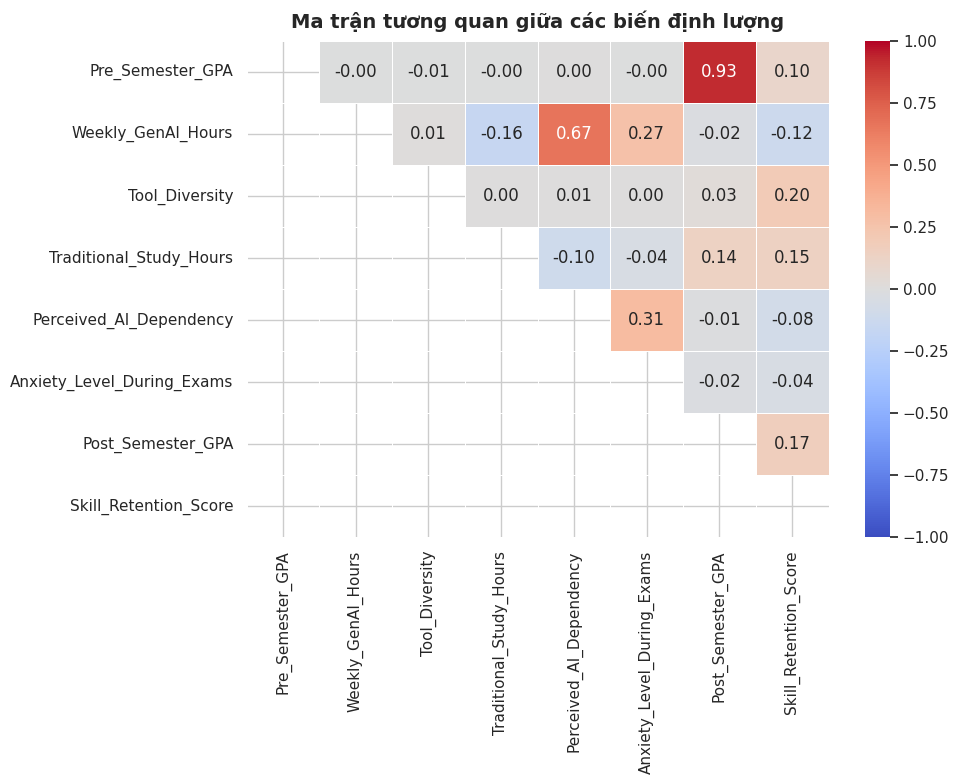

In [13]:
# Ma trận tương quan
corr_matrix = df[numerical_cols].corr()
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.6, vmin=-1, vmax=1)

plt.title('Ma trận tương quan giữa các biến định lượng', fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét**
- **Pre_Semester_GPA và Post_Semester_GPA** có hệ số tương quan lên tới 0.93, nếu đưa cả hai vào các mô hình tuyến tính sẽ bị nhiễu trọng số. Nên cân nhắc chỉ giữ lại một biến hoặc tạo ra biến mới bằng cách kết hợp 2 biến này lại

- **Weekly_GenAI_Hours và Perceived_AI_Dependency** có tương quan khá mạnh với nhau (0.67). Đồng thời sự phụ thuộc này lại tương quan dương với Anxiety_Level_During_Exams (0.31). Khi sinh viên giành nhiều thời gian cho AI thì mức độ phụ thuộc càng cao và tâm lý lo lắng khi vào phòng thi cũng tăng lên do lúc đấy ko được dùng AI.


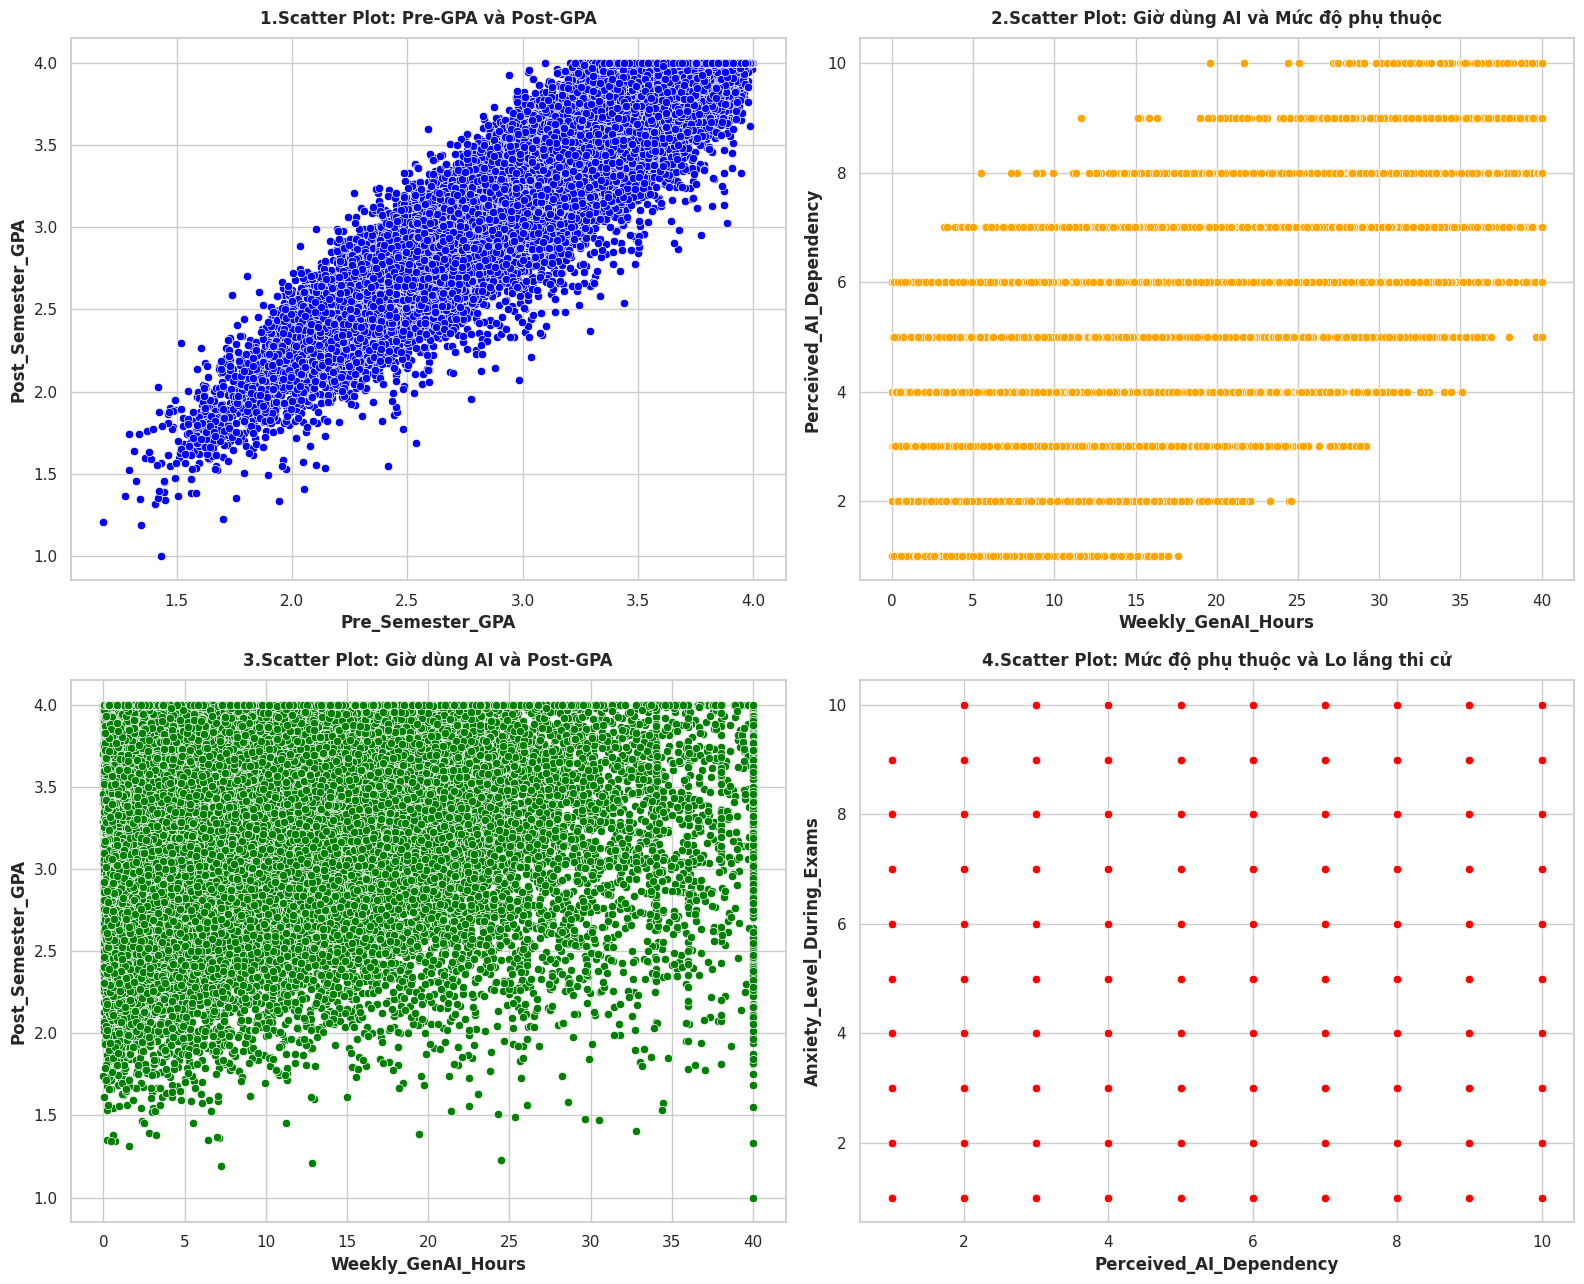

In [16]:
# Scatter plot

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# Pre_Semester_GPA và Post_Semester_GPA
sns.scatterplot(x='Pre_Semester_GPA', y='Post_Semester_GPA', data=df, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('1.Scatter Plot: Pre-GPA và Post-GPA', fontsize=12, weight='bold')

# Weekly_GenAI_Hours và Perceived_AI_Dependency
sns.scatterplot(x='Weekly_GenAI_Hours', y='Perceived_AI_Dependency', data=df, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('2.Scatter Plot: Giờ dùng AI và Mức độ phụ thuộc', fontsize=12, weight='bold')

# Weekly_GenAI_Hours và Post_Semester_GPA
sns.scatterplot(x='Weekly_GenAI_Hours', y='Post_Semester_GPA', data=df, ax=axes[1, 0], color='green')
axes[1, 0].set_title('3.Scatter Plot: Giờ dùng AI và Post-GPA', fontsize=12, weight='bold')

# Perceived_AI_Dependency và Anxiety_Level_During_Exams
sns.scatterplot(x='Perceived_AI_Dependency', y='Anxiety_Level_During_Exams', data=df, ax=axes[1, 1], color='red')
axes[1, 1].set_title('4.Scatter Plot: Mức độ phụ thuộc và Lo lắng thi cử', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Pre-GPA và Post-GPA**: Các chấm tạo dải dốc lên rõ rệt. Tuyến tính thuận cực mạnh (0.93), minh chứng cho hiện tượng đa cộng tuyến.
- **Giờ dùng AI và Mức độ phụ thuộc**: Mật độ chấm dịch dần lên các bậc thang cao hơn. Tuyến tính thuận (0.67), dùng nhiều nên bị lệ thuộc.
- **Giờ dùng AI và Post-GPA**: Phi tuyến tính (-0.02).
- **Mức độ phụ thuộc và Lo lắng thi cử**: Tuyến tính thuận mức vừa (0.31), lệ thuộc AI cao làm tăng áp lực phòng thi.

## Categorical Features (Thanh Hoàng)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu (object, category, bool).
  - Kiểm tra số lượng giá trị duy nhất (Cardinality - nunique). Lưu ý đặc biệt: Nếu một biến định tính có quá nhiều nhóm (ví dụ >50 nhóm), cần cảnh báo vì sẽ khó mã hóa sau này.

  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) và đề xuất hướng xử lý (điền bằng nhóm xuất hiện nhiều nhất - Mode, hoặc tạo một nhóm mới tên là "Unknown").

- Thống kê mô tả & Tần suất:
  - Lập bảng tần suất (Count) và tần suất phần trăm (Percentage) cho từng danh mục.
  - Trực quan hóa bằng biểu đồ cột (Bar chart) hoặc biểu đồ tròn (Pie chart - chỉ dùng khi có ít hơn 5 danh mục) để xem có sự mất cân bằng giữa các nhóm hay không.

- Mối tương quan:
  - Sử dụng Crosstab để xem tần suất kết hợp giữa các biến định tính quan trọng với nhau.

In [ ]:
categorical_data=df.select_dtypes(include=['object','bool'])
categorical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Major_Category            50000 non-null  object
 1   Year_of_Study             50000 non-null  object
 2   Primary_Use_Case          50000 non-null  object
 3   Prompt_Engineering_Skill  50000 non-null  object
 4   Paid_Subscription         50000 non-null  bool  
 5   Institutional_Policy      50000 non-null  object
 6   Burnout_Risk_Level        50000 non-null  object
dtypes: bool(1), object(6)
memory usage: 2.7+ MB


## Correlation Analysis (Minh Hoàng)

Yêu cầu:
- Kiểm tra dữ liệu:
  - Kiểm tra phân phối của biến mục tiêu. Nếu bị lệch quá nhiều (Skewed), cần đề xuất các phương pháp biến đổi (như Log Transformation) để chuẩn hóa dữ liệu.

- Phân tích Đa biến :
  - Dùng điểm tương hỗ MI (Mutual Information) để lọc ra các biến quan trọng với biến mục tiêu. Từ đó, xem xét các mối quan hệ xoay quanh những biến có điểm MI cao.
  - Biến mục tiêu và các biến định lượng: Vẽ biểu đồ Boxplot hoặc Violin Plot của biến định lượng theo từng nhóm của Target (nếu Target là định tính), hoặc vẽ Scatter Plot (nếu cả hai là định lượng) để xem biến định lượng nào tác động mạnh đến Target.

  - Biến mục tiêu và biến dịnh tính: Vẽ biểu đồ cột chồng hoặc biểu đồ tỉ lệ để xem tỷ lệ phân bố của Target thay đổi như thế nào trên từng danh mục.

# Step 2: Data Preprocessing

Yêu cầu:
- clean: xử lý dữ liệu bị khuyết, trùng lặp, sửa lỗi định dạng và kiểu dữ liệu
- encode: mã hóa các biến phân loại
- impute: điền vào các giá trị NaN

In [ ]:
def load_data():
    # Read data
    data_dir = "/content/ai_student_impact_dataset.csv"
    df = pd.read_csv(data_dir, index_col="Student_Id")
    # Preprocessing
    df = clean(df)
    df = encode(df)
    df = impute(df)

    # Reform splits
    df = df.loc[df.index, :]
    return df

### Clean data

In [ ]:
def clean(df):
  ''' Hàm làm sạch dữ liệu'''
  return df


### Impute data

In [ ]:
def impute(df):
  ''' Hàm thêm các giá trị khuyết'''
  return df

### Encode data

In [ ]:
def encode(df):
  ''' Hàm mã hóa dữ liệu'''
  return df


# Step 3: Feature Engineering

# Step 4: Modelling